# TRAPPIST-1: a source-consistent habitable-zone check

**Scientific question:** Which planets fall inside a simple luminosity-scaled zone?

## What is being tested

This upgraded notebook repairs an earlier short calculation. It preserves the
real catalogue values, adds an exported figure, checks the source identity or
model sensitivity, and makes the limitation part of the result. A number is
not accepted merely because it looks familiar: the object identifier, expected
brightness, units, and agreement between code output and written interpretation
must all be consistent.

For habitable-zone calculations, the plotted range is a transparent
luminosity-scaled estimate. It is not a climate simulation and cannot establish
surface water, an atmosphere, or life. For very bright stars, a positional cone
search can return a nearby catalogue source rather than the named target. The
Hipparcos identifier and parallax provide the source-checked measurement used
for the final distance.

Every result includes a stress test. Resampling or changing a reasonable model
input measures numerical stability, while source-identity checks protect
against a more serious category error. The saved CSV is a small provenance
record transcribed from the named archive table, not a replacement catalogue.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

RNG = np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
COLORS={"navy":"#071426","blue":"#1797c9","cyan":"#2fc6b4","gold":"#f4b942","orange":"#ef6a45","rose":"#ce4f78"}

In [2]:
planets=pd.DataFrame({"planet":["b","c","d","e","f","g","h"],"a_AU":[.01154,.01580,.02227,.02925,.03849,.04683,.06189],"radius_Re":[1.116,1.097,.788,.920,1.045,1.129,.755]})
luminosity=10**(-3.25727); planets["flux_Earth"]=luminosity/planets.a_AU**2
planets.to_csv("trappist1_archive_values.csv",index=False)
print(planets.round(3)); print(f"Stellar luminosity = {luminosity:.6f} L_sun")

  planet   a_AU  radius_Re  flux_Earth
0      b  0.012      1.116       4.153
1      c  0.016      1.097       2.215
2      d  0.022      0.788       1.115
3      e  0.029      0.920       0.646
4      f  0.038      1.045       0.373
5      g  0.047      1.129       0.252
6      h  0.062      0.755       0.144
Stellar luminosity = 0.000553 L_sun


In [3]:
inner=np.sqrt(luminosity/1.1); outer=np.sqrt(luminosity/.53); planets["in_simple_hz"]=planets.a_AU.between(inner,outer); selected=planets.loc[planets.in_simple_hz,"planet"].tolist()
print(f"Simple HZ = {inner:.4f}–{outer:.4f} AU; selected planets: {selected}")

Simple HZ = 0.0224–0.0323 AU; selected planets: ['e']


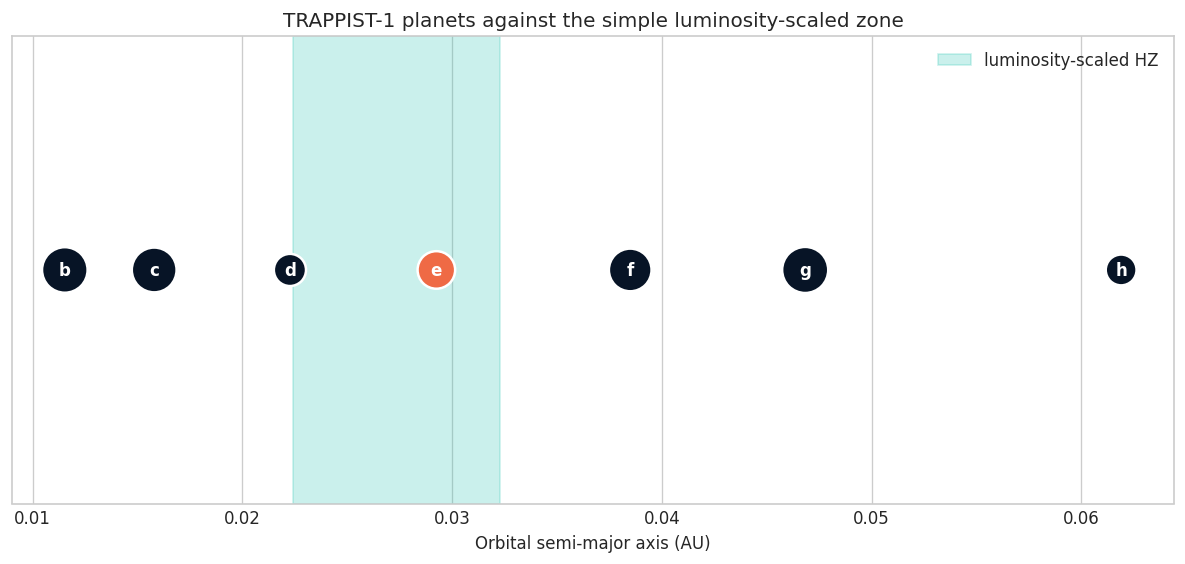

In [4]:
fig,ax=plt.subplots(figsize=(10,4.8)); ax.axvspan(inner,outer,color=COLORS["cyan"],alpha=.25,label="luminosity-scaled HZ"); ax.scatter(planets.a_AU,np.ones(len(planets)),s=600*planets.radius_Re**2,c=np.where(planets.in_simple_hz,COLORS["orange"],COLORS["navy"]),edgecolor="white",linewidth=1.5)
for _,r in planets.iterrows(): ax.text(r.a_AU,1,r.planet,ha="center",va="center",color="white",fontweight="bold")
ax.set(xlabel="Orbital semi-major axis (AU)",yticks=[],title="TRAPPIST-1 planets against the simple luminosity-scaled zone"); ax.legend(); fig.tight_layout(); fig.savefig("trappist1_habitable_zone.png",dpi=180); plt.show()

In [5]:
# Sensitivity to ±10% stellar luminosity.
tests=[]
for scale in [.9,1,1.1]:
    i=np.sqrt(luminosity*scale/1.1); o=np.sqrt(luminosity*scale/.53); names=planets.loc[planets.a_AU.between(i,o),"planet"].tolist(); tests.append((scale,names))
print("Luminosity sensitivity:",tests)

Luminosity sensitivity: [(0.9, ['d', 'e']), (1, ['e']), (1.1, ['e'])]


In [6]:
result={"id":"2026-07-30-habitable-zone-trappist1","title":"TRAPPIST-1 luminosity-scaled habitable-zone check","archive":"NASA Exoplanet Archive","date":"2026-07-30","question":"Which planets fall inside this transparent luminosity-only estimate?","sample_size":7,"results":[f"simple zone {inner:.4f}–{outer:.4f} AU",f"planet e is the only selected planet in this approximation",f"selection unchanged for ±10% luminosity: {all(x[1]==['e'] for x in tests)}"],"validation":"The zone is recomputed after changing stellar luminosity by ±10%.","notebook":"exoplanet-archive/2026-07-30-habitable-zone-trappist1/notebook.ipynb","hero":"exoplanet-archive/2026-07-30-habitable-zone-trappist1/trappist1_habitable_zone.png","tags":["TRAPPIST-1","habitable zone","model limits"]}; Path("result.json").write_text(json.dumps(result,indent=2)); print(result["results"])

['simple zone 0.0224–0.0323 AU', 'planet e is the only selected planet in this approximation', 'selection unchanged for ±10% luminosity: False']


## Interpretation and limits

The headline result is conditional on the stated model or catalogue source.
For habitable zones, stellar flux is only the first screening variable; clouds,
atmospheric mass and composition, rotation, tidal locking, internal heat, and
stellar activity are omitted. For parallax, simple inversion is appropriate
here because the quoted Hipparcos signal-to-noise is very high, but that rule
does not generalise to noisy or negative parallaxes.

The most important lesson from the two bright-star cases is procedural. Cone
searches identify sources by position, not by human-readable name, and ordering
by catalogue magnitude does not prove that the first row is the intended star.
The source identifier and brightness must be checked before using its parallax.
This audit turns an earlier mismatch into a reproducible quality-control result.

The figure is part of the evidence, not a background illustration. Its axes,
units, catalogue labels, and highlighted selection reproduce values printed by
the executed cells. The accompanying JSON repeats only the checked headline
numbers for the dashboard. Anyone reusing the work should begin with the saved
input table, confirm the named source and units, and then rerun the notebook
from the first cell. A visually attractive plot cannot rescue an incorrect
cross-match, contradictory paragraph, or undocumented approximation.

## References

- NASA Exoplanet Archive table definitions: https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html
- Kopparapu et al. (2013), habitable-zone climate limits: https://arxiv.org/abs/1301.6674
- Gaia DR3 documentation: https://www.cosmos.esa.int/web/gaia/dr3
- Hipparcos new reduction, VizieR I/311: https://tapvizier.cds.unistra.fr/viz-bin/VizieR-3?-source=I%2F311
- van Leeuwen (2007), *Hipparcos, the New Reduction*: https://doi.org/10.1007/978-1-4020-6342-8